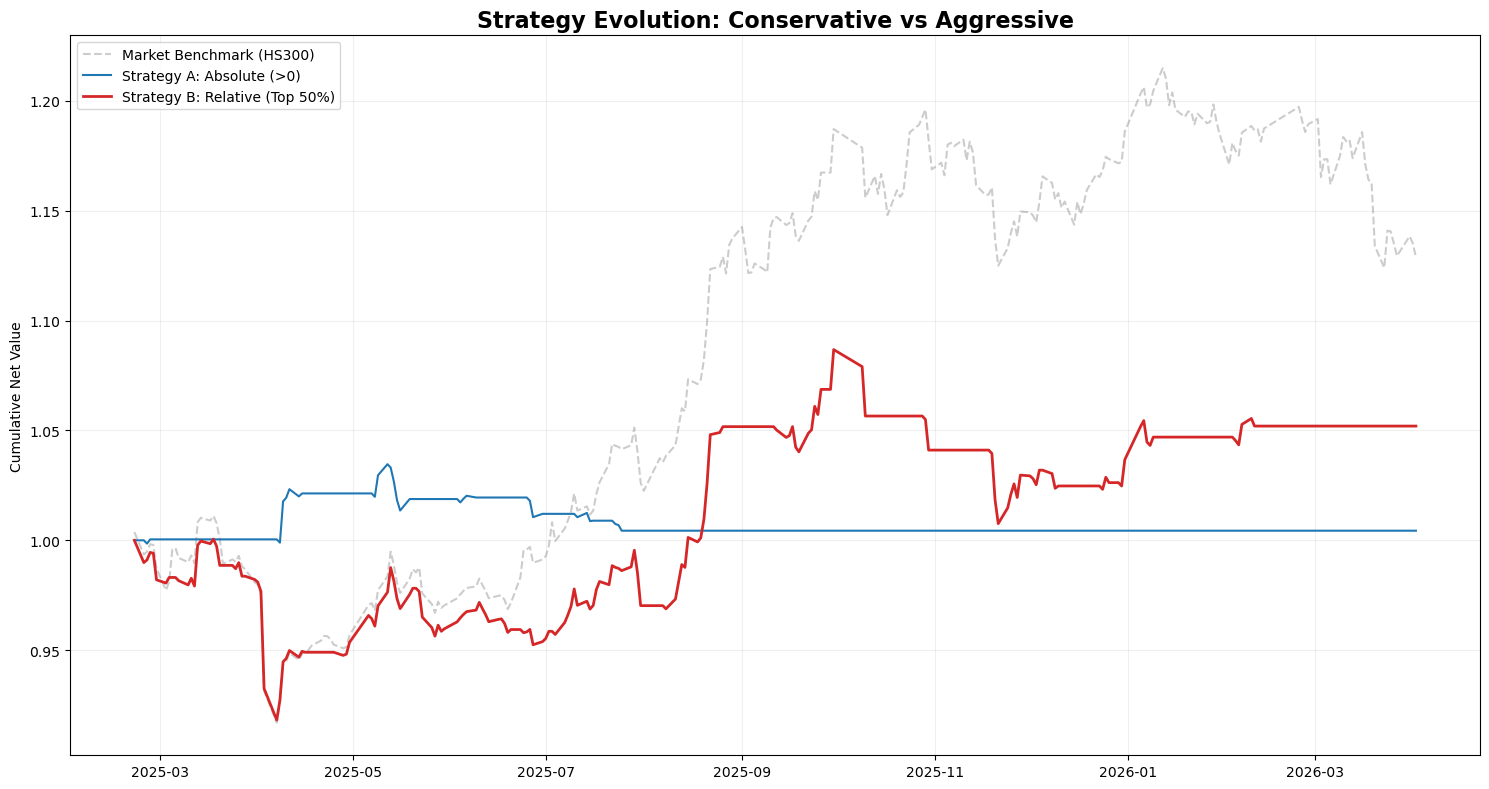


 策略表现对比表:
                   Name Total Return Sharpe MaxDD
Absolute (Conservative)        0.44%   0.17 2.93%
  Relative (Aggressive)        5.20%   0.55 8.23%


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class QuantBacktester:
    def __init__(self, df, fees=0.001, slippage=0.0005):
        self.df = df.copy()
        self.df['date'] = pd.to_datetime(self.df['date'])
        self.cost = fees + slippage
        
    def backtest(self, threshold=0, signal_type='absolute'):
        """
        核心回测函数
        signal_type: 
            'absolute' - 基于预测涨幅阈值
            'relative' - 基于排名分位数（Month 5 思想）
        """
        temp_df = self.df.copy()
        
         # 1. 信号生成
        if signal_type == 'absolute':
            temp_df['signal'] = np.where(temp_df['pred'] > threshold, 1, 0)
        elif signal_type == 'relative':
            # 只要预测值在排名前 50% 就买入（尝试破解踏空）
            temp_df['signal'] = np.where(temp_df['pred'] > temp_df['pred'].median(), 1, 0)
            
        # 2. 计算收益与成本
        temp_df['pos_diff'] = temp_df['signal'].diff().abs().fillna(0)
        temp_df['strat_ret_raw'] = temp_df['signal'].shift(1) * temp_df['actual']
        temp_df['trade_cost'] = temp_df['pos_diff'] * self.cost
        temp_df['strat_ret_net'] = temp_df['strat_ret_raw'] - temp_df['trade_cost']
        
        # 3. 计算净值
        temp_df['cum_strategy'] = (1 + temp_df['strat_ret_net'].fillna(0)).cumprod()
        temp_df['cum_market'] = (1 + temp_df['actual']).cumprod()
        
        return temp_df
        
# --- 执行重构后的回测 ---
results_df = pd.read_csv('final_performance_results.csv')
tester = QuantBacktester(results_df)

# 测试两种策略：一个是原来的阈值法，一个是相对排名法
res_abs = tester.backtest(threshold=0, signal_type='absolute')
res_rel = tester.backtest(signal_type='relative')

# --- 1. 定义一个健壮的指标计算函数 ---
def get_metrics(df, name):
    # 强制转换为 numpy 数组，规避所有 Pandas 维度报错
    cum_strategy = df['cum_strategy'].values
    net_returns = df['strat_ret_net'].fillna(0).values
    
    # 总收益
    total_ret = cum_strategy[-1] - 1
    
    # 夏普比率 (年化)
    std = net_returns.std()
    sharpe = (net_returns.mean() / std * np.sqrt(252)) if std != 0 else 0
    
    # 最大回撤 (MDD) - 使用 numpy 的方式计算，最稳妥
    running_max = np.maximum.accumulate(cum_strategy)
    drawdowns = (cum_strategy - running_max) / running_max
    max_dd = np.abs(np.min(drawdowns))
    
    return {
        'Name': name, 
        'Total Return': f"{total_ret:.2%}", 
        'Sharpe': f"{sharpe:.2f}", 
        'MaxDD': f"{max_dd:.2%}"
    }

# --- 2. 运行对比绘图 ---
plt.figure(figsize=(15, 8), dpi=100)

# 准备绘图数据
dates = pd.to_datetime(res_abs['date']).values
market = res_abs['cum_market'].values
strat_a = res_abs['cum_strategy'].values
strat_b = res_rel['cum_strategy'].values

plt.plot(dates, market, label='Market Benchmark (HS300)', color='gray', alpha=0.4, linestyle='--')
plt.plot(dates, strat_a, label='Strategy A: Absolute (>0)', color='#1f77b4', linewidth=1.5)
plt.plot(dates, strat_b, label='Strategy B: Relative (Top 50%)', color='#d62728', linewidth=2)

plt.title('Strategy Evolution: Conservative vs Aggressive', fontsize=16, fontweight='bold')
plt.ylabel('Cumulative Net Value')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# --- 3. 打印对比表格 ---
metrics_list = [
    get_metrics(res_abs, "Absolute (Conservative)"),
    get_metrics(res_rel, "Relative (Aggressive)")
]
metrics_df = pd.DataFrame(metrics_list)
print("\n 策略表现对比表:")
print(metrics_df.to_string(index=False))

##### 对比两种策略
##### 相对排名法（新策略：只要预测值高于中位数就买，强制进攻）

In [7]:
res_rel.to_csv('strategy_v2_aggressive.csv', index=False)

In [1]:
import sys
print("核心路径在这里：", sys.executable)

核心路径在这里： C:\Users\DELL\anaconda3\python.exe
